# Import Libraries and load the file

In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\JV_Portfolio_TestFiles\Cardholder_Complaints.csv')
df.head()

,complaint_id,customer_id,complaint_date,complaint_type,channel,status,resolution_date,disputed_amount
0,1001,501,5/3/2024,unrecognized_charge,call_center,closed,5/10/2024,120.50
1,1002,502,5/4/2024,card_declined,web,closed,5/6/2024,0.00
2,1003,503,5/5/2024,billing_error,app,open,NaN,35.00
3,1004,504,5/6/2024,unrecognized_charge,call_center,closed,5/12/2024,18.99
4,1005,505,5/7/2024,rewards_issue,web,closed,5/9/2024,0.00


# Dataset General Information

In [33]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   complaint_id     20 non-null     int64  
 1   customer_id      20 non-null     int64  
 2   complaint_date   20 non-null     str    
 3   complaint_type   20 non-null     str    
 4   channel          20 non-null     str    
 5   status           20 non-null     str    
 6   resolution_date  16 non-null     str    
 7   disputed_amount  20 non-null     float64
dtypes: float64(1), int64(2), str(5)
memory usage: 1.4 KB


,complaint_id,customer_id,complaint_date,complaint_type,channel,status,resolution_date,disputed_amount
count,20.00000,20.00000,20,20,20,20,16,20.000000
unique,NaN,NaN,20,5,3,2,16,NaN
top,NaN,NaN,5/3/2024,unrecognized_charge,call_center,closed,5/10/2024,NaN
freq,NaN,NaN,1,6,7,16,1,NaN
mean,1010.50000,510.50000,NaN,NaN,NaN,NaN,NaN,22.799000
std,5.91608,5.91608,NaN,NaN,NaN,NaN,NaN,53.708618
min,1001.00000,501.00000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,1005.75000,505.75000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,1010.50000,510.50000,NaN,NaN,NaN,NaN,NaN,2.500000
75%,1015.25000,515.25000,NaN,NaN,NaN,NaN,NaN,12.937500


# Complaints Type Count

In [34]:
df['complaint_type'].value_counts()


complaint_type
unrecognized_charge    6
card_declined          4
billing_error          4
card_not_received      4
rewards_issue          2
Name: count, dtype: int64

# Channel Distribution

In [35]:
df['channel'].value_counts()

channel
call_center    7
web            7
app            6
Name: count, dtype: int64

# Complaint Status

In [36]:
df['status'].value_counts()


status
closed    16
open       4
Name: count, dtype: int64

# Dispute Amount Statistics

In [37]:
df['disputed_amount'].describe()


count     20.000000
mean      22.799000
std       53.708618
min        0.000000
25%        0.000000
50%        2.500000
75%       12.937500
max      220.000000
Name: disputed_amount, dtype: float64

# Top Disputes

In [38]:
df[['complaint_id','complaint_type','disputed_amount']]\
    .sort_values(by='disputed_amount', ascending=False)\
    .head(5)


,complaint_id,complaint_type,disputed_amount
10,1011,unrecognized_charge,220.00
0,1001,unrecognized_charge,120.50
2,1003,billing_error,35.00
3,1004,unrecognized_charge,18.99
12,1013,billing_error,15.75


# Resolution Time

In [39]:
df['complaint_date'] = pd.to_datetime(df['complaint_date'])
df['resolution_date'] = pd.to_datetime(df['resolution_date'], errors='coerce')
df 

,complaint_id,customer_id,complaint_date,complaint_type,channel,status,resolution_date,disputed_amount
0,1001,501,2024-05-03,unrecognized_charge,call_center,closed,2024-05-10,120.50
1,1002,502,2024-05-04,card_declined,web,closed,2024-05-06,0.00
2,1003,503,2024-05-05,billing_error,app,open,NaT,35.00
3,1004,504,2024-05-06,unrecognized_charge,call_center,closed,2024-05-12,18.99
4,1005,505,2024-05-07,rewards_issue,web,closed,2024-05-09,0.00
5,1006,506,2024-05-08,card_not_received,call_center,closed,2024-05-15,0.00
6,1007,507,2024-05-09,card_declined,app,open,NaT,0.00
7,1008,508,2024-05-10,unrecognized_charge,web,closed,2024-05-14,9.50
8,1009,509,2024-05-11,billing_error,call_center,closed,2024-05-13,12.00
9,1010,510,2024-05-12,card_not_received,app,closed,2024-05-18,0.00


# Resolution Days

In [40]:
df['resolution_days'] = (df['resolution_date'] - df['complaint_date']).dt.days
df[df['status'] == 'closed'][['complaint_id','complaint_type','resolution_days']]
df


,complaint_id,customer_id,complaint_date,complaint_type,channel,status,resolution_date,disputed_amount,resolution_days
0,1001,501,2024-05-03,unrecognized_charge,call_center,closed,2024-05-10,120.50,7.0
1,1002,502,2024-05-04,card_declined,web,closed,2024-05-06,0.00,2.0
2,1003,503,2024-05-05,billing_error,app,open,NaT,35.00,NaN
3,1004,504,2024-05-06,unrecognized_charge,call_center,closed,2024-05-12,18.99,6.0
4,1005,505,2024-05-07,rewards_issue,web,closed,2024-05-09,0.00,2.0
5,1006,506,2024-05-08,card_not_received,call_center,closed,2024-05-15,0.00,7.0
6,1007,507,2024-05-09,card_declined,app,open,NaT,0.00,NaN
7,1008,508,2024-05-10,unrecognized_charge,web,closed,2024-05-14,9.50,4.0
8,1009,509,2024-05-11,billing_error,call_center,closed,2024-05-13,12.00,2.0
9,1010,510,2024-05-12,card_not_received,app,closed,2024-05-18,0.00,6.0


# Average Resolution Days

In [41]:
df[df['status'] == 'closed']['resolution_days'].mean()


np.float64(4.3125)

# Anomalies Detection
# Open Cases Without Resolution Date

In [42]:
df[(df['status'] == 'open') & (df['resolution_date'].isna())]


,complaint_id,customer_id,complaint_date,complaint_type,channel,status,resolution_date,disputed_amount,resolution_days
2,1003,503,2024-05-05,billing_error,app,open,NaT,35.00,NaN
6,1007,507,2024-05-09,card_declined,app,open,NaT,0.00,NaN
12,1013,513,2024-06-03,billing_error,app,open,NaT,15.75,NaN
16,1017,517,2024-06-07,card_declined,web,open,NaT,0.00,NaN


# Dispute Amount Outliers

In [43]:
q1 = df['disputed_amount'].quantile(0.25)
q3 = df['disputed_amount'].quantile(0.75)
iqr = q3 - q1

outliers = df[df['disputed_amount'] > q3 + 1.5 * iqr]
outliers



,complaint_id,customer_id,complaint_date,complaint_type,channel,status,resolution_date,disputed_amount,resolution_days
0,1001,501,2024-05-03,unrecognized_charge,call_center,closed,2024-05-10,120.5,7.0
2,1003,503,2024-05-05,billing_error,app,open,NaT,35.0,NaN
10,1011,511,2024-06-01,unrecognized_charge,web,closed,2024-06-05,220.0,4.0


# Combined Distribution Complaint_Type - Channel

In [44]:
df.groupby(['complaint_type','channel']).size().reset_index(name='total')


,complaint_type,channel,total
0,billing_error,app,3
1,billing_error,call_center,1
2,card_declined,app,1
3,card_declined,call_center,1
4,card_declined,web,2
5,card_not_received,app,2
6,card_not_received,call_center,1
7,card_not_received,web,1
8,rewards_issue,call_center,1
9,rewards_issue,web,1


# Visualizations

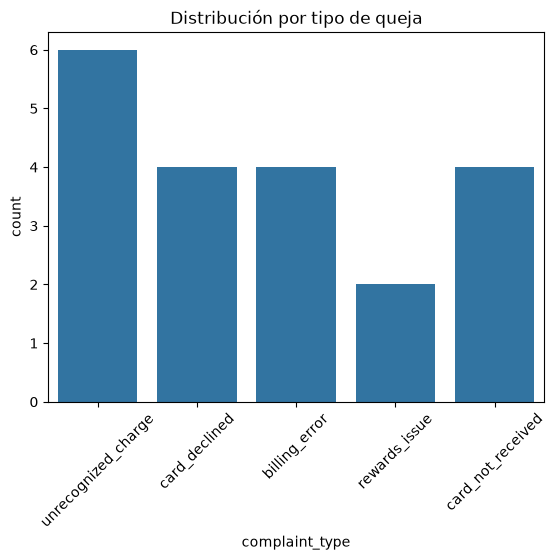

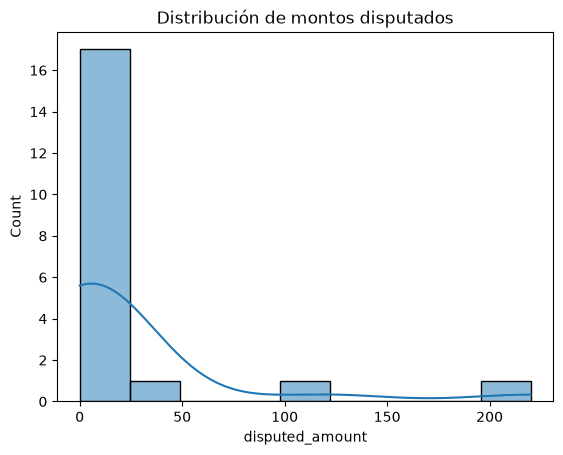

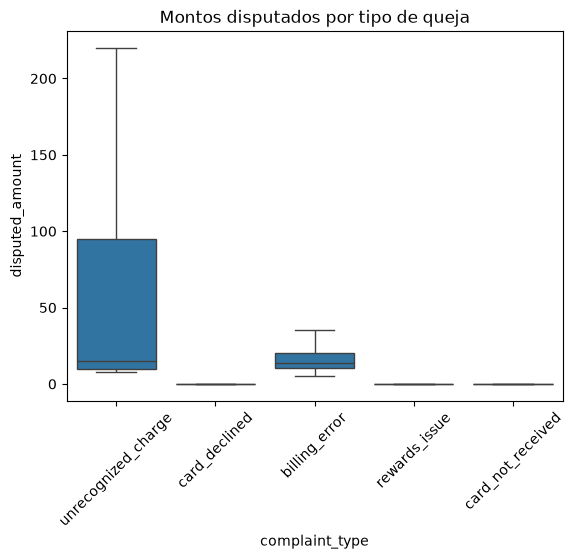

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='complaint_type')
plt.xticks(rotation=45)
plt.title("Distribución por tipo de queja")
plt.show()

sns.histplot(df['disputed_amount'], kde=True)
plt.title("Distribución de montos disputados")
plt.show()

sns.boxplot(data=df, x='complaint_type', y='disputed_amount')
plt.xticks(rotation=45)
plt.title("Montos disputados por tipo de queja")
plt.show()
